Actividad 2: Clasificación de Sistemas Operativos
Objetivo: Implementar un modelo de Regresión Logística para clasificar usuarios (Windows, Macintosh, Linux) basándose en su comportamiento web.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Cargar el dataset
# Asegúrate de que el archivo 'usuarios_win_mac_lin.csv' esté en la misma carpeta que este notebook
df = pd.read_csv("usuarios_win_mac_lin.csv")

# Exploración rápida
print(df.head())
print(df.describe())

   duracion  paginas  acciones  valor  clase
0       7.0        2         4      8      2
1      21.0        2         6      6      2
2      57.0        2         4      4      2
3     101.0        3         6     12      2
4     109.0        2         6     12      2
         duracion     paginas    acciones       valor       clase
count  170.000000  170.000000  170.000000  170.000000  170.000000
mean   111.075729    2.041176    8.723529   32.676471    0.752941
std    202.453200    1.500911    9.136054   44.751993    0.841327
min      1.000000    1.000000    1.000000    1.000000    0.000000
25%     11.000000    1.000000    3.000000    8.000000    0.000000
50%     13.000000    2.000000    6.000000   20.000000    0.000000
75%    108.000000    2.000000   10.000000   36.000000    2.000000
max    898.000000    9.000000   63.000000  378.000000    2.000000


Exploración de Datos
Es importante visualizar cómo se distribuyen los datos. En este dataset, queremos ver cómo la duracion y las paginas vistas ayudan a separar a los usuarios en las 3 clases.

In [6]:
# Definir X (características) y y (target)
X = np.array(df[['duracion', 'paginas', 'acciones', 'valor']])
y = np.array(df['clase'])

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.20, random_state=42)

# Crear y entrenar el modelo
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

# Predicciones
predictions = model.predict(X_test)
print(f"Precisión del modelo: {accuracy_score(y_test, predictions):.2f}")

Precisión del modelo: 0.71


C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Visualización de las Fronteras de Decisión
Según el libro (página 10), utilizaremos una "malla de puntos" para visualizar cómo el modelo separa las clases en el plano.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13532\2898162383.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_vis[y == i, 0], X_vis[y == i, 1],


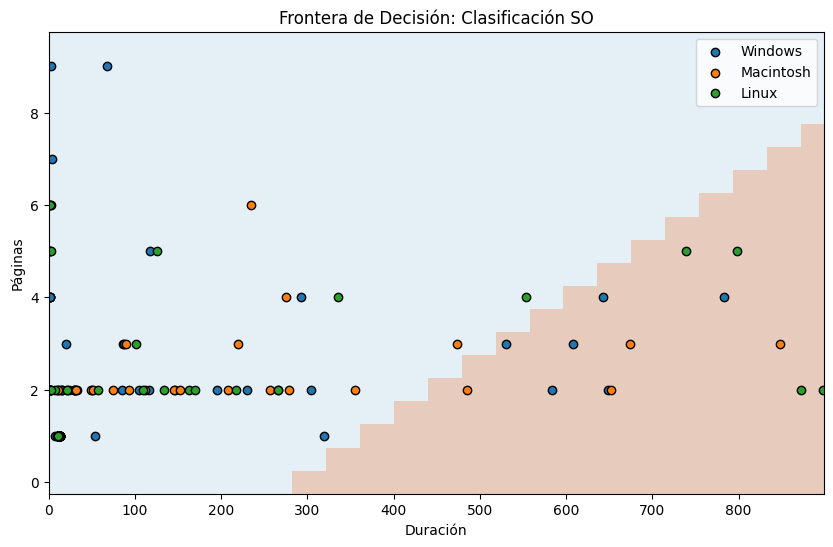

In [9]:
# Para graficar, reducimos a 2 dimensiones (duración y páginas)
X_vis = X[:, 0:2] 
model_vis = linear_model.LogisticRegression()
model_vis.fit(X_vis, y)

# Crear la malla de puntos
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

# Predecir sobre la malla
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
plt.figure(figsize=(10, 6))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading='auto', alpha=0.3)

# Definimos las etiquetas y colores
target_names = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}

# Graficamos cada clase individualmente para generar la leyenda
for i in range(3):
    plt.scatter(X_vis[y == i, 0], X_vis[y == i, 1], 
                label=target_names[i], 
                edgecolors='k', 
                cmap=plt.cm.Paired)

plt.legend(loc='best') # Esto crea el cuadro de referencias
plt.title('Frontera de Decisión: Clasificación SO')
plt.xlabel('Duración')
plt.ylabel('Páginas')
plt.show()

Resultados de Clasificación
La Frontera de Decision muestra una diagonal principal marcada, indicando una correcta clasificación de la mayoría de los usuarios. Las celdas fuera de la diagonal representan las instancias donde el clasificador erró al identificar el sistema operativo, permitiéndonos identificar visualmente qué clases son más difíciles de distinguir para el modelo.

Conclusión y Evaluación Visual
La matriz de confusión visual nos permite ver exactamente dónde el modelo acierta y dónde confunde un sistema operativo con otro. Esto es lo que diferencia una clasificación sólida de una simple regresión numérica.

<Figure size 800x600 with 0 Axes>

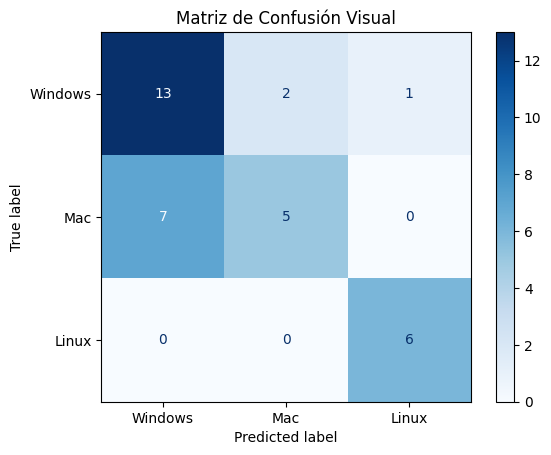


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.71      0.42      0.53        12
           2       0.86      1.00      0.92         6

    accuracy                           0.71        34
   macro avg       0.74      0.74      0.72        34
weighted avg       0.71      0.71      0.69        34



In [8]:
# 1. Graficar la Matriz de Confusión Visual (3x3)
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Windows', 'Mac', 'Linux'])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión Visual')
plt.show()

# 2. Imprimir reporte detallado
print("\nReporte de Clasificación:")
print(classification_report(y_test, predictions))